In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


df = pd.read_csv('data/mutant_metrics.csv')
df = df[~df['attacker'].isin(['gpt-4.1-nano', 'gpt-3.5-turbo', 'claude-3-7-sonnet-latest', 'gpt-4o', 'gpt-4o-mini'])]
df = df[~df['defender'].isin(['gpt-4.1-nano', 'gpt-3.5-turbo', 'claude-3-7-sonnet-latest', 'gpt-4o', 'gpt-4o-mini'])]
df = df[~(df['class_alias']=='MathOps')]

name_map = {
    "gpt-4.1-mini": "GPT 4.1-mini",
    "gpt-4.1": "GPT 4.1",
    "claude-3-5-haiku-latest": "Claude Haiku 3.5",
    "claude-sonnet-4-0": "Claude Sonnet 4.0",
    "gemini-2.5-flash": "Gemini 2.5 Flash",
    "gemini-2.5-pro": "Gemini 2.5 Pro"
}


df = df.replace({"attacker": name_map, "defender": name_map})
df = df.rename(columns={"attacker": "Attacker", "defender": "Defender"})
df = df.fillna(0)
df['Score Attacker'] = df['score']
df['Score Defender'] = 1 - df['score']

df_scores = df[['Attacker', 'Score Attacker']].rename(columns={'Attacker': 'Model', 'Score Attacker': 'Score'})
df_scores = pd.concat([df_scores, df[['Defender', 'Score Defender']].rename(columns={'Defender': 'Model', 'Score Defender': 'Score'})], ignore_index=True)

df_aggregated = df.groupby(["Attacker", "Defender"]).mean(numeric_only=True).reset_index()
df_aggregated

,Attacker,Defender,score,mut_forfeit,mut_equivalent,mut_survived_turn,mut_survived_game,Score Attacker,Score Defender
0,Claude Haiku 3.5,Claude Haiku 3.5,0.040000,0.315000,0.366513,0.680711,0.067541,0.040000,0.960000
1,Claude Haiku 3.5,Claude Sonnet 4.0,0.025000,0.315000,0.280280,0.649038,0.033399,0.025000,0.975000
2,Claude Haiku 3.5,GPT 4.1,0.025000,0.350000,0.353443,0.405421,0.067692,0.025000,0.975000
3,Claude Haiku 3.5,GPT 4.1-mini,0.050000,0.380000,0.485658,0.425974,0.135931,0.050000,0.950000
4,Claude Haiku 3.5,Gemini 2.5 Flash,0.005000,0.490000,0.354363,0.283209,0.007692,0.005000,0.995000
5,Claude Haiku 3.5,Gemini 2.5 Pro,0.000000,0.470000,0.391015,0.228093,0.000000,0.000000,1.000000
6,Claude Sonnet 4.0,Claude Haiku 3.5,0.000000,0.800000,0.293122,0.611111,0.000000,0.000000,1.000000
7,Claude Sonnet 4.0,Claude Sonnet 4.0,0.000000,0.683333,0.249092,0.650030,0.000000,0.000000,1.000000
8,Claude Sonnet 4.0,GPT 4.1,0.000000,0.683333,0.352623,0.554040,0.000000,0.000000,1.000000
9,Claude Sonnet 4.0,GPT 4.1-mini,0.000000,0.750000,0.202525,0.468254,0.000000,0.000000,1.000000


/tmp/ipykernel_612/335967456.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
/tmp/ipykernel_612/335967456.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)


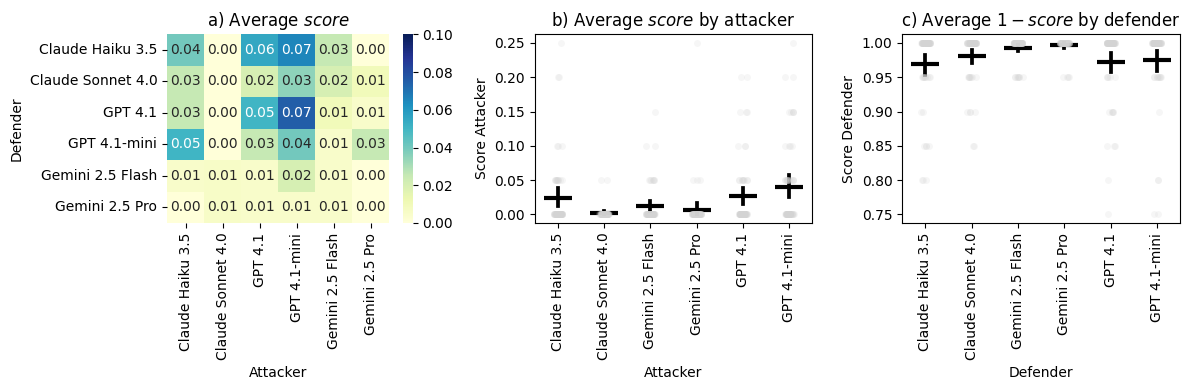

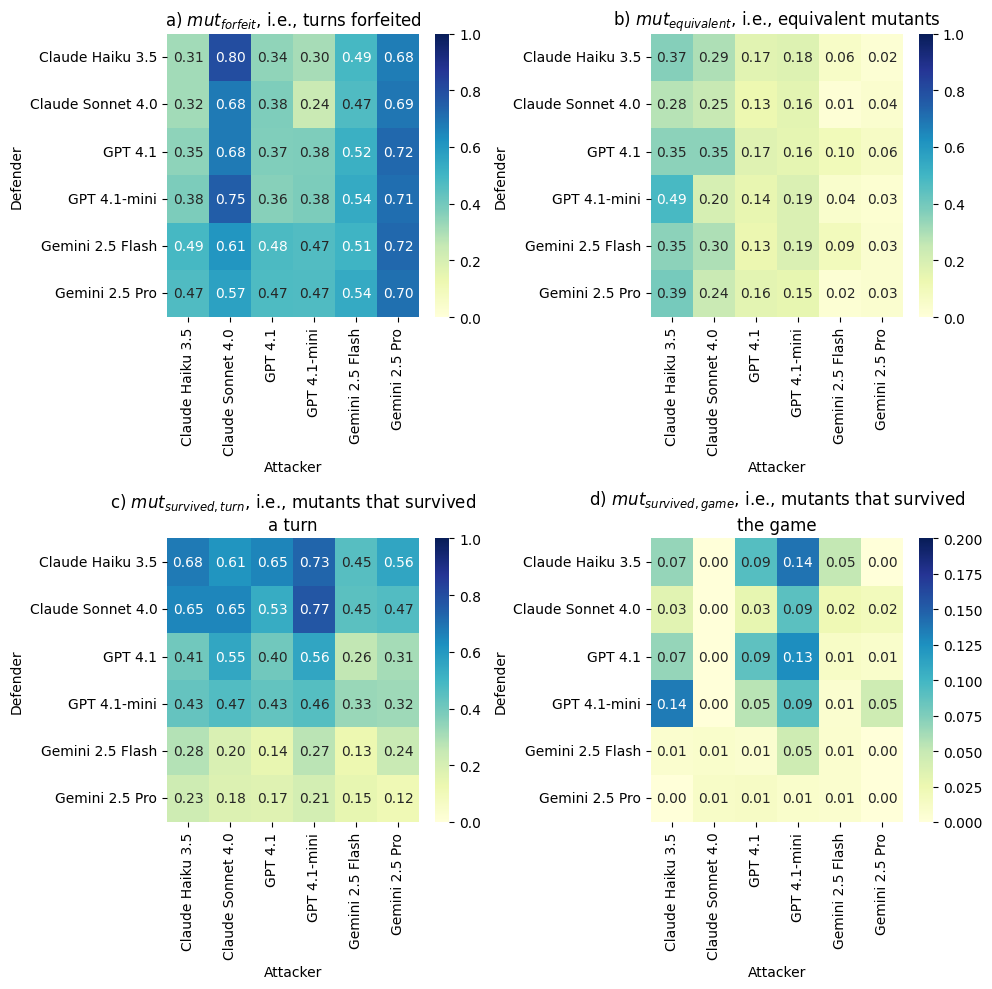

In [5]:
pivot_df_score = df_aggregated.pivot(columns="Attacker", index="Defender", values="score")
pivot_df_forfeit = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_forfeit")
pivot_df_equivalent = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_equivalent")
pivot_df_survived_turn = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_survived_turn")
pivot_df_survived_game = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_survived_game")

rot_x=90
rot_y=0
bar_color = "lightblue"
point_color = "lightgrey"
bar_color = 'black'
errorbar_type = "ci"
cbar_vmin = 0
cbar_vmax = 1

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax = axes[0]
sns.heatmap(pivot_df_score, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax, vmin=cbar_vmin, vmax=0.1)
ax.set_title("a) Average $score$")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)

ax = axes[1]
sns.stripplot(data=df, x="Attacker", y="Score Attacker", ax=ax, color=point_color, dodge=True, alpha=.2, legend=False)
sns.pointplot(data=df, x="Attacker", y="Score Attacker", ax=ax, color=bar_color, errorbar=errorbar_type, linestyle="none", marker="_", markersize=20, markeredgewidth=3)
ax.set_title("b) Average $score$ by attacker")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

ax = axes[2]
sns.stripplot(data=df, x="Defender", y="Score Defender", ax=ax, color=point_color, dodge=True, alpha=.2, legend=False)
sns.pointplot(data=df, x="Defender", y="Score Defender", ax=ax, color=bar_color, errorbar=errorbar_type, linestyle="none", marker="_", markersize=20, markeredgewidth=3)
ax.set_title("c) Average $1-score$ by defender")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

# ax = axes[3]
# sns.stripplot(data=df_scores, x="Model", y="Score", ax=ax, color=point_color, dodge=True, alpha=.2, legend=False)
# sns.pointplot(data=df_scores, x="Model", y="Score", ax=ax, color=bar_color, errorbar=errorbar_type, linestyle="none", marker="_", markersize=20, markeredgewidth=3)
# ax.set_title("d) Average of $score$ for the attacker and \n$1-score$ the defender by model")
# ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

plt.tight_layout()
plt.savefig("figures/scores.pdf", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2,2, figsize=(10, 10))

ax = axes[0,0]
sns.heatmap(pivot_df_forfeit, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("a) $mut_{forfeit}$, i.e., turns forfeited")

ax = axes[0,1]
sns.heatmap(pivot_df_equivalent, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("b) $mut_{equivalent}$, i.e., equivalent mutants")

ax = axes[1,0]
sns.heatmap(pivot_df_survived_turn, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("c) $mut_{survived,turn}$, i.e., mutants that survived\na turn")

ax = axes[1,1]
sns.heatmap(pivot_df_survived_game, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=0.2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("d) $mut_{survived,game}$, i.e., mutants that survived\nthe game")

plt.tight_layout()
plt.savefig("figures/mutations.pdf", bbox_inches='tight')
plt.show()

In [3]:
metrics_map = {
    "score": "$score$",
    "mut_forfeit": "$mut_{forfeit}$",
    "mut_equivalent": "$mut_{equivalent}$",
    "mut_survived_turn": "$mut_{survived,turn}$",
    "mut_survived_game": "$mut_{survived,game}$"
}

df_aggregated = df_aggregated.rename(columns=metrics_map)
df_aggregated.drop(columns=["Score Attacker", "Score Defender"], inplace=True)

results_tex = df_aggregated.to_latex(index=False, float_format="%.2f")
print(results_tex)

\begin{tabular}{llrrrrr}
\toprule
Attacker & Defender & $score$ & $mut_{forfeit}$ & $mut_{equivalent}$ & $mut_{survived,turn}$ & $mut_{survived,game}$ \\
\midrule
Claude Haiku 3.5 & Claude Haiku 3.5 & 0.04 & 0.31 & 0.37 & 0.68 & 0.07 \\
Claude Haiku 3.5 & Claude Sonnet 4.0 & 0.03 & 0.32 & 0.28 & 0.65 & 0.03 \\
Claude Haiku 3.5 & GPT 4.1 & 0.03 & 0.35 & 0.35 & 0.41 & 0.07 \\
Claude Haiku 3.5 & GPT 4.1-mini & 0.05 & 0.38 & 0.49 & 0.43 & 0.14 \\
Claude Haiku 3.5 & Gemini 2.5 Flash & 0.01 & 0.49 & 0.35 & 0.28 & 0.01 \\
Claude Haiku 3.5 & Gemini 2.5 Pro & 0.00 & 0.47 & 0.39 & 0.23 & 0.00 \\
Claude Sonnet 4.0 & Claude Haiku 3.5 & 0.00 & 0.80 & 0.29 & 0.61 & 0.00 \\
Claude Sonnet 4.0 & Claude Sonnet 4.0 & 0.00 & 0.68 & 0.25 & 0.65 & 0.00 \\
Claude Sonnet 4.0 & GPT 4.1 & 0.00 & 0.68 & 0.35 & 0.55 & 0.00 \\
Claude Sonnet 4.0 & GPT 4.1-mini & 0.00 & 0.75 & 0.20 & 0.47 & 0.00 \\
Claude Sonnet 4.0 & Gemini 2.5 Flash & 0.01 & 0.61 & 0.30 & 0.20 & 0.01 \\
Claude Sonnet 4.0 & Gemini 2.5 Pro & 0.01 & 

In [10]:
import autorank

score_pivot_df_attacker = pd.pivot_table(df[['class_alias', 'Attacker', 'Defender', 'Score Attacker']], index=['class_alias', 'Defender'], columns=['Attacker'])
score_pivot_df_defender = pd.pivot_table(df[['class_alias', 'Attacker', 'Defender', 'Score Defender']], index=['class_alias', 'Attacker'], columns=['Defender'])

res_attacker = autorank.autorank(score_pivot_df_attacker, approach='bayesian', nsamples=10000, force_mode='parametric', rope_mode='absolute', rope=0.01)
res_defender = autorank.autorank(score_pivot_df_defender, approach='bayesian', nsamples=10000, force_mode='parametric', rope_mode='absolute', rope=0.01)

autorank.latex_table(res_attacker, effect_size_relation="both", posterior_relation="both")
autorank.latex_table(res_defender, effect_size_relation="both", posterior_relation="both")

\begin{table}[h]
\centering
\begin{tabular}{llrrlllllrrlrrl}
\toprule
 &  & M & SD & CI & $\gamma$ (best) & Magnitude (best) & $\gamma$ (above) & Magnitude (above) & $P(\textit{equal})$ (best) & $P(\textit{smaller})$ (best) & Decision (best) & $P(\textit{equal})$ (above) & $P(\textit{smaller})$ (above) & Decision (above) \\
 & Attacker &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Score Attacker} & GPT 4.1-mini & 0.040 & 0.062 & [0.000, 0.100] & 0.000 & negligible & 0.000 & negligible & - & - & - & - & - & - \\
 & GPT 4.1 & 0.027 & 0.052 & [0.000, 0.050] & 0.233 & small & 0.233 & small & 0.256 & 0.703 & inconclusive & 0.256 & 0.703 & inconclusive \\
 & Claude Haiku 3.5 & 0.024 & 0.052 & [0.000, 0.050] & 0.275 & small & 0.048 & negligible & 0.128 & 0.849 & inconclusive & 0.284 & 0.462 & inconclusive \\
 & Gemini 2.5 Flash & 0.012 & 0.030 & [0.000, 0.000] & 0.581 & medium & 0.293 & small & 0.149 & 0.851 & inconclusive & 0.888 & 0.111 & inconclusive \\
 & Gemini 2.

In [12]:
score_pivot_df_attacker = pd.pivot_table(df[df['class_alias']!='Options'][['class_alias', 'Attacker', 'Defender', 'Score Attacker']], index=['class_alias', 'Defender'], columns=['Attacker'])
#score_pivot_df_defender = pd.pivot_table(df[['class_alias', 'Attacker', 'Defender', 'Score Defender']], index=['class_alias', 'Attacker'], columns=['Defender'])

res_attacker = autorank.autorank(score_pivot_df_attacker, approach='bayesian', nsamples=1000, force_mode='parametric', rope_mode='absolute', rope=0.01)
#res_defender = autorank.autorank(score_pivot_df_defender, approach='bayesian', nsamples=10000, force_mode='parametric')

autorank.latex_table(res_attacker, effect_size_relation="both", posterior_relation="both")


\begin{table}[h]
\centering
\begin{tabular}{llrrlllllrrlrrl}
\toprule
 &  & M & SD & CI & $\gamma$ (best) & Magnitude (best) & $\gamma$ (above) & Magnitude (above) & $P(\textit{equal})$ (best) & $P(\textit{smaller})$ (best) & Decision (best) & $P(\textit{equal})$ (above) & $P(\textit{smaller})$ (above) & Decision (above) \\
 & Attacker &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Score Attacker} & GPT 4.1-mini & 0.040 & 0.062 & [0.000, 0.100] & 0.000 & negligible & 0.000 & negligible & - & - & - & - & - & - \\
 & GPT 4.1 & 0.027 & 0.052 & [0.000, 0.050] & 0.233 & small & 0.233 & small & 0.251 & 0.710 & inconclusive & 0.251 & 0.710 & inconclusive \\
 & Claude Haiku 3.5 & 0.024 & 0.052 & [0.000, 0.050] & 0.275 & small & 0.048 & negligible & 0.130 & 0.853 & inconclusive & 0.281 & 0.467 & inconclusive \\
 & Gemini 2.5 Flash & 0.012 & 0.030 & [0.000, 0.000] & 0.581 & medium & 0.293 & small & 0.145 & 0.855 & inconclusive & 0.899 & 0.099 & inconclusive \\
 & Gemini 2.

In [8]:
res_defender = autorank.autorank(merged_scores.dropna().iloc[:, 2:], approach='bayesian', nsamples=1000)

autorank.latex_table(res_defender, effect_size_relation="both", posterior_relation="both")

\begin{table}[h]
\centering
\begin{tabular}{lrllllrrlrrl}
\toprule
 & MED & MAD & CI & $\gamma$ (above) & Magnitude (above) & $P(\textit{equal})$ (best) & $P(\textit{smaller})$ (best) & Decision (best) & $P(\textit{equal})$ (above) & $P(\textit{smaller})$ (above) & Decision (above) \\
\midrule
Gemini 2.5 Flash & 0.950 & 0.050 & [0.000, 1.000] & 0.000 & negligible & - & - & - & - & - & - \\
Gemini 2.5 Pro & 0.950 & 0.050 & [0.000, 1.000] & 0.002 & negligible & 1.000 & 0.000 & equal & 1.000 & 0.000 & equal \\
Claude Sonnet 4.0 & 0.900 & 0.100 & [0.000, 1.000] & 0.021 & negligible & 0.972 & 0.028 & equal & 1.000 & 0.000 & equal \\
GPT 4.1 & 0.850 & 0.150 & [0.000, 1.000] & -0.016 & negligible & 0.919 & 0.050 & inconclusive & 0.871 & 0.001 & inconclusive \\
Claude Haiku 3.5 & 0.800 & 0.200 & [0.000, 1.000] & 0.006 & negligible & 0.940 & 0.059 & inconclusive & 1.000 & 0.000 & equal \\
GPT 4.1-mini & 0.800 & 0.200 & [0.000, 1.000] & -0.021 & negligible & 0.947 & 0.007 & inconclusive & 1.000 